This notebook reproduces the example from scDesign package: [Simulate spatial transcriptomic data](https://songdongyuan1994.github.io/scDesign3/docs/articles/scDesign3-spatial-vignette.html)

In [1]:
from scdesigner.datasets import visium
import anndata

example_sce = visium()

In [2]:
example_sce = example_sce[:, :10].to_memory()
example_sce.obs

,orig.ident,nCount_Spatial,nFeature_Spatial,slice,region,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,seurat_clusters,spatial1,spatial2,cell_type
AAACAAGTATCTCCCA-1,anterior1,13069.0,4242,1.0,anterior,23817.0,4710,2,2,7475,8501,2
AAACACCAATAACTGC-1,anterior1,37448.0,7860,1.0,anterior,25085.0,7425,5,5,8553,2788,5
AAACAGAGCGACTCCT-1,anterior1,28475.0,6332,1.0,anterior,25455.0,6326,3,3,3164,7950,3
AAACAGCTTTCAGAAG-1,anterior1,39718.0,7957,1.0,anterior,24862.0,7326,11,11,6637,2099,11
AAACAGGGTCTATATT-1,anterior1,33392.0,7791,1.0,anterior,25288.0,7673,11,11,7116,2375,11
...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGTTTCCCGAAAG-1,anterior1,27417.0,6539,1.0,anterior,25422.0,6537,1,1,7595,5541,1
TTGTTCAGTGTGCTAC-1,anterior1,29222.0,6388,1.0,anterior,25381.0,6386,6,6,4362,5885,6
TTGTTGTGTGTCAAGA-1,anterior1,22285.0,5747,1.0,anterior,23705.0,5745,1,1,5200,6780,1
TTGTTTCACATCCAGG-1,anterior1,16724.0,4371,1.0,anterior,23607.0,4483,4,4,8434,4371,4


This is not quite the simulator used in the scDesign3 vignette, because we are using the same copula correlation across all groups. We need a version of negative_binomial_copula that takes a grouping variable in the formula as well.

In [3]:
from scdesigner.simulators import SpatialNegBinCopula

sim = SpatialNegBinCopula(mean_extra_terms="cell_type", basis="tps")
sim.fit(example_sce)

Epoch 65/500, Loss: 1.9110, Val Loss: 1.9683


Estimating copula correlation: 100%|██████████| 3/3 [00:00<00:00, 48.24it/s]


In [4]:
simulated = sim.sample()

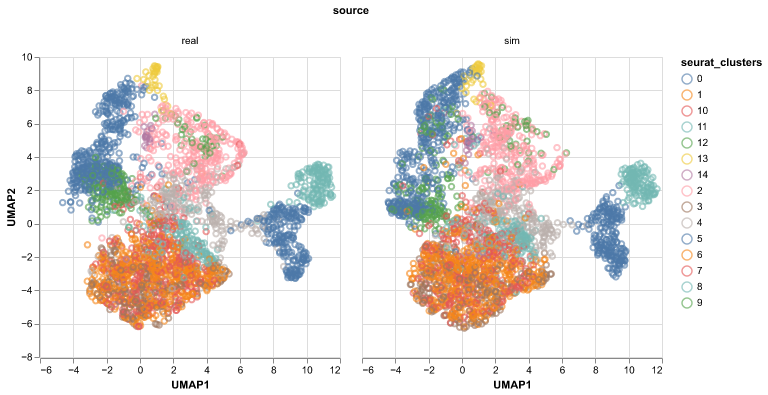

In [5]:
import altair
from scdiagnostics import plot_umap
altair.renderers.enable('png')
altair.data_transformers.enable("vegafusion")

combined = anndata.concat({"real": example_sce, "sim": simulated}, label="source")
plot_umap(combined, color="seurat_clusters", facet="source", n_comps=5)

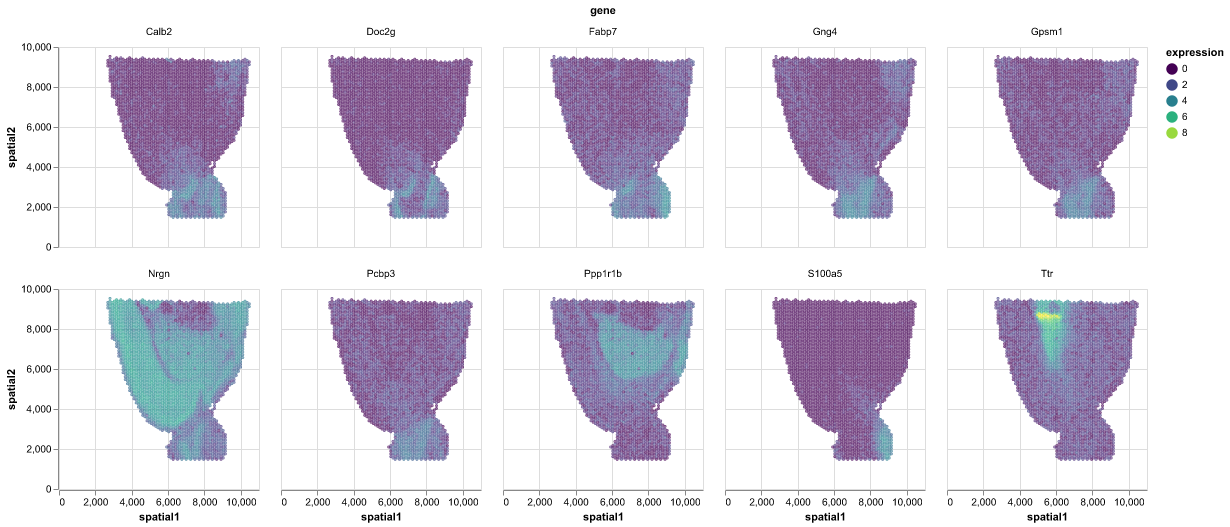

In [6]:
from scdiagnostics import plot_spatial

plot_spatial(example_sce)

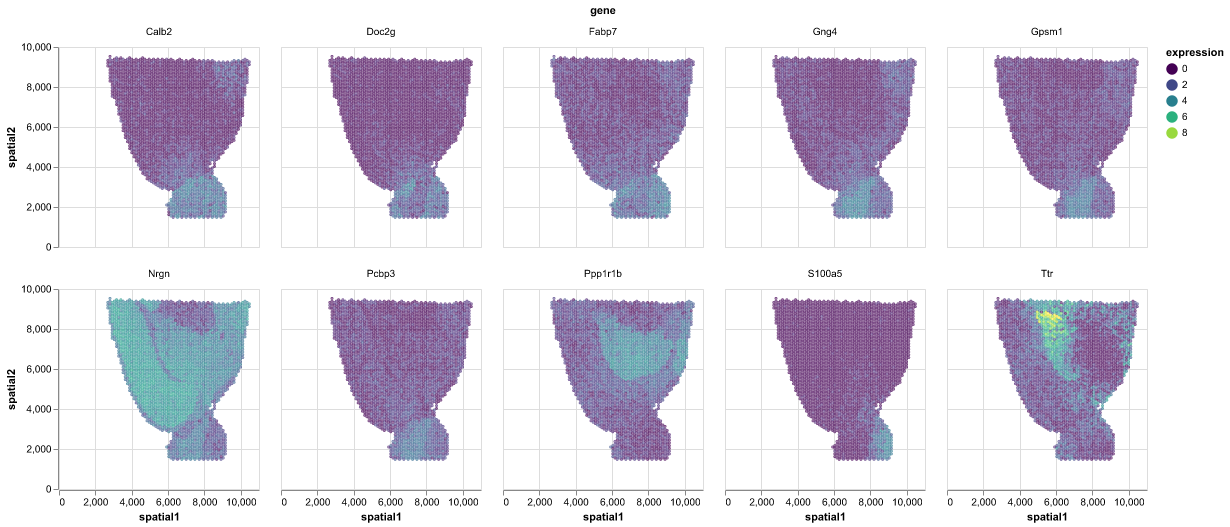

In [7]:
plot_spatial(simulated)